# Lab 2: Subgradient Method

**Student: Viktoriia Vlasenko, 2088928**


In this lab, we will implement the subgradient method.

In [82]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from random import randrange, choice

# pseudo-random number generator (used for reproducibility)
rnd_state = np.random.RandomState(12)


## Introduction

Let us consider the following minimization problem
$$
\min\limits_{x \in \mathbb{R}^d} f(x) := | x |.
$$


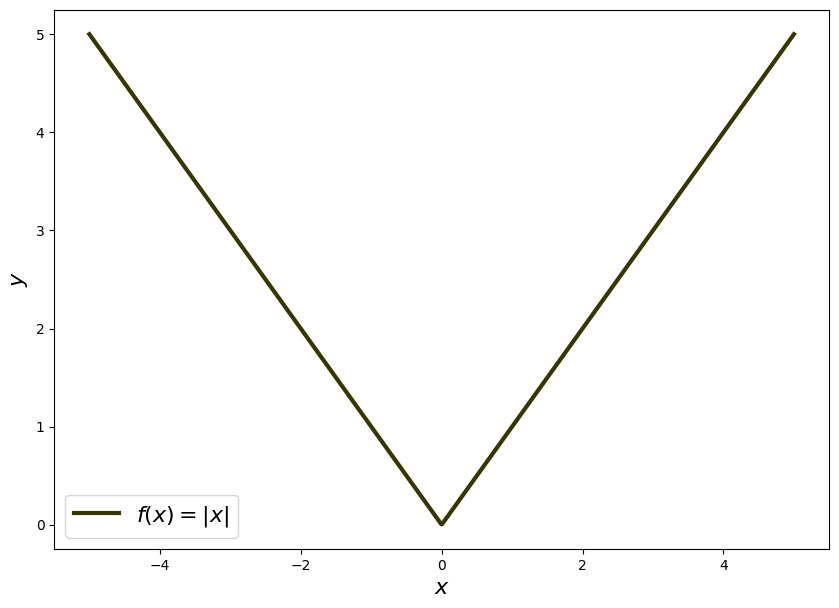

In [83]:
def target(x):
  return abs(x) # abs computes the absolute value

X = np.linspace(-5, 5, 1000) # 1000 points in [-5, 5]
y = target(X)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(X, y, '-', c=[0.21, 0.21, 0.001], lw=3, label='$f(x) = |x|$')
ax.set_xlabel("$x$", fontsize=16)
ax.set_ylabel("$y$", fontsize=16)
_ = ax.legend(fontsize=16)


Since $f$ is not differentiable at $x = 0$, we cannot use gradient descent to solve the problem.

### Subgradient and subdifferential
To solve the previous problem (and in general to handle cases where the objective function is not smooth), we introduce the concept of subgradient and define an algorithm known as ***sub-gradient method***.

**subdifferential**: given a function  $f : \mathbb{R}^d \to \mathbb{R}$, for every $x \in \mathbb{R}^d$, we define the subdifferential $\partial f(x)$ as follows

$$
\partial f(x) := \{ g \in \mathbb{R}^d  \,|\, f(z) \geq f(x) + u^\intercal (z - x) \quad \forall z \in \mathbb{R}^d \}.
$$

For each $x \in \mathbb{R}^d$, we also define a subgradient $u$ at $x$ as an element of $\partial f(x)$.





Furthermore, it is possible to prove that if $f$ is differentiable at $x$ then
$$
\partial f(x) = \{ \nabla f(x) \}.
$$

Going back to the previous example (i.e. $f(x) = |x|$) we have that

$$
\partial f(x) = \left\{
  \begin{array}{ll}
    \{ 1\} & x > 0 \\
    \{ -1\} & x < 0 \\
    [-1, 1] & x = 0
    \end{array}
  \right.
$$
Therefore, a subgradient $u$ of $f$ at $x$ will be
$$
u = \left\{
  \begin{array}{ll}
    1 & x > 0 \\
    -1 & x < 0 \\
    \in [-1, 1] & x = 0
    \end{array}
  \right.
$$
For illustration purposes, let us implement a function `sample_subgrad(x)` that given an `x` (float), returns a subgradient of $f(x)$

In [84]:
def sample_subgrad(x):
  if x != 0: # if x is not 0 then returns 1 if x > 0, -1 otherwise
    return np.sign(x) # np.sign returns 1 if x > 0, -1 if x < 0 (and 0 if x = 0)
  return 2 * rnd_state.rand(1) - 1 # the function rand(d) returns d values in [0, 1)


Now, fixing $x_0 = 0$, we can plot for each $x$,
$$
\phi(x) := f(x_0) + u (x - x_0),
$$
verifying (empirically) that it is a lower-bound of $f$ (as follows from the definition of subgradient).


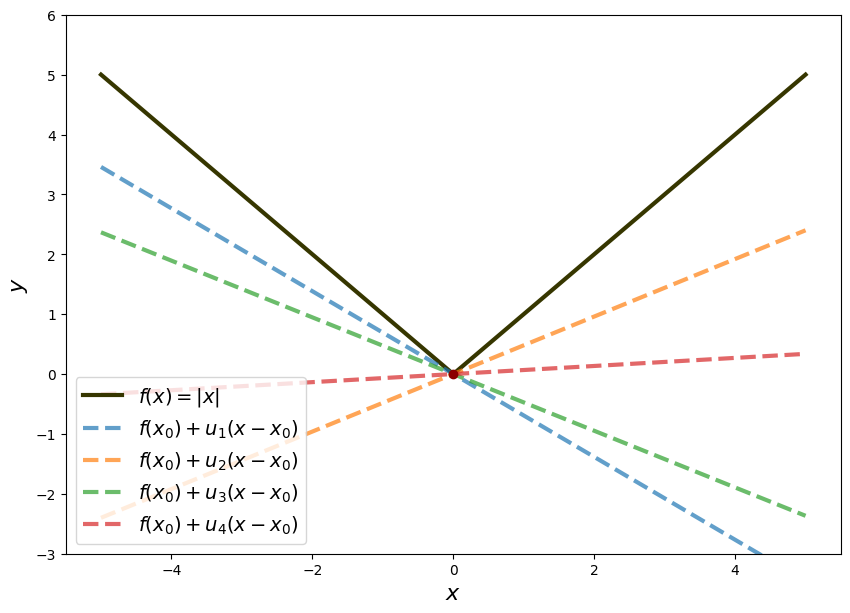

In [85]:
x_0 = 0.0

lower_bounds = []
for i in range(4):
  # sample 4 subgradients at x_0 and compute [f(x_0) + u_i * (x - x_0)] for i = 1, ..., 4
  u = sample_subgrad(x_0) # sample a subgradient
  lb = [target(x_0) + u*(x - x_0) for x in X]  # compute phi(x) for each x in X (space discretization)
  lower_bounds.append(lb)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(X, y, '-', c=[0.21, 0.21, 0.001], lw=3, label='$f(x) = |x|$')
for i, lb in enumerate(lower_bounds): # plot the lists containing phi(x) for different subgradients
  ax.plot(X, lb, '--',  alpha=0.7, lw=3, label='$f(x_0) + u_{} (x - x_0)$'.format(i + 1))
ax.plot(0.0, 0.0, 'o', c='darkred')
ax.set_xlabel("$x$", fontsize=16)
ax.set_ylabel("$y$", fontsize=16)
ax.set_ylim([-3.0, 6.0])
_ = ax.legend(loc='lower left', fontsize=14)


### Subgradient method


Given a point $x_0 \in \mathbb{R}^d$ and a sequence $(\gamma_k)_{k \in \mathbb{N}}$, we define the subgradient method as the following iteration:
$$
x_{k + 1} = x_k - \gamma_k u_k \qquad \text{with} \qquad u_k \in \partial f(x_k).
$$


The subgradient method is not (necessarily) a descent algorithm, hence we keep track of the best evaluation $f^{\text{best}}_k$ found at time-step $k$ i.e.
$$
f^{\text{best}}_k := \min\limits_{i = 0, \cdots, k} f(x_i).
$$

## Exercise 1: Polyhedral function
Let us now consider the following problem. Let $f : \mathbb{R}^2 \to \mathbb{R}$,
$$
\min\limits_{x \in \mathbb{R}^2} f(x) := 5 |x_1| + 2 |x_2|
$$


___
Useful functions:
- [numpy.linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)
- [numpy.meshgrid](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html)
- [numpy.linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)
- [numpy.random.rand](https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html)

Text(0, 0.5, '$y$')

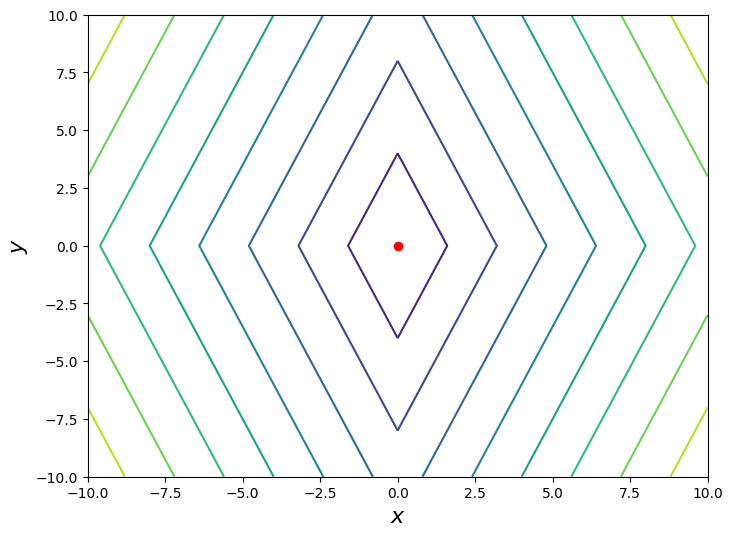

In [86]:
x1 = np.linspace(-10,  10, 1000)
x2 = np.linspace(-10,  10, 1000)

X, Y = np.meshgrid(x1, x2)

Z =  5 * abs(X) + 2.0 * abs(Y)


fig, ax= plt.subplots(figsize=(8, 6))
ax.plot(0.0, 0.0, 'o', c='red')
ax.contour(X, Y, Z, levels = 10)
ax.set_xlabel("$x$", fontsize=16)
ax.set_ylabel("$y$", fontsize=16)



Recall that
1. if $f(x) = f_1(x_1) + f_2(x_2) + \cdots + f_m(x_m)$ with $(f_i)_{i=1}^m$ convex functions, then
$$
(\forall x \in \mathbb{R}^d) \qquad\partial f(x) = \partial f_1(x_1) \times \cdots \times \partial f_m(x_m).
$$

2. Let $f : \mathbb{R}^d \to \mathbb{R}$ be a convex function and let $\alpha > 0$. If we define
$$
h(x) := \alpha f(x),
$$
then
$$
(\forall x \in \mathbb{R}^d) \qquad \partial h(x) = \alpha \partial f(x).
$$

Going back to the previous function, a subgradient $u$ of $f$ at $x$ will be $u \in \mathbb{R}^2$ with
$$
u_1 = \left\{
  \begin{array}{ll}
    -5 & x_1 < 0\\
    5 & x_1 > 0\\
    v \in [-5, 5] & x_1=0
  \end{array}
  \right. \qquad
\text{and} \qquad
u_2 = \left\{
  \begin{array}{ll}
    -2 & x_2 < 0\\
    2 & x_2 > 0\\
    \in [-2, 2] & x_2=0
  \end{array}
  \right.
$$
Where $u_1, u_2$ are respectively the first and second entries of the vector $u$.

Let us implement a function `sample_subgrad(x)` that given a numpy array $x$, returns a subgradient of $f$ at $x$.

In [87]:
def target(x):
  return 5.0 *abs(x[0]) + 2.0 * abs(x[1])

def sample_subgrad(x):
  # TODO: return a subgradient of f at x
  u = np.zeros_like(x, dtype=float)
  x1 = x[0]
  x2 = x[1]

  if x1 > 0:
    u[0] = 5.0
  elif x1 < 0:
    u[0] = -5.0
  else:
    u[0] = randrange(-5, 5)

  if x2 > 0:
    u[1] = 2.0
  elif x2 < 0:
    u[1] = -2.0
  else:
    u[1] = randrange(-2, 2)
  return u

Now let us implement the function `subgrad_method(x0, gamma, max_iter, target, sample_subgrad)` that will perform subgradient method to minimize the function $f$ introduced previously.

The parameters of this function are the following:
- `x0`: initial point (a numpy array of dimension 2)
- `gamma`: step-size (constant)
- `max_iter`: number of iterations
- `target`: target function (i.e. $f$)
- `sample_subgrad`: function that allows sampling a subgradient

Note that the last two parameters allow us to avoid rewriting the code for other functions, making the `subgrad_method` function more general.

This function should return:
- `x`: the last iterate
- `f_vals`: a numpy array containing the function values at the iterates
- `x_obs` : a numpy array of size max_iter $\times 2$ containing the trajectory (i.e. the observed iterates)
- `f_best` : a numpy array of size max_iter such that each entry $k$ contains $f^\text{best}_k$

In [88]:
def subgrad_method(x0, gamma, max_iter, target, sample_subgrad):
  f_vals = np.empty(max_iter + 1)
  f_best = np.empty(max_iter + 1)
  x_obs = np.empty((max_iter + 1, x0.shape[0]))
  x = x0.copy()
  f_min = target(x) # best f(x)
  f_vals[0] = f_min
  f_best[0] = f_min
  x_obs[0] = x.copy()

  for t in range(max_iter):
    u = sample_subgrad(x).flatten()
    # TODO: implement subgradient method
    x = x - gamma * u
    fx = target(x)
    f_vals[t + 1] = fx
    x_obs[t + 1] = x.copy()
    if f_min > fx:
      f_min = fx
    f_best[t + 1] = f_min
  return x, f_vals, x_obs, f_best

From theory, we know that if we consider the following iteration
$$
x_{k + 1} = x_k - \gamma_k u_k \qquad u_k \in \partial f(x_k)
$$
and we assume that $f$ $L$-Lipschitz is continous (and therefore $\| u\|_2 \leq L$ for every $u \in \partial f(x)$ for every $x$), we have that
$$
f^{best}_k - f(x^*) \leq \frac{\| x_0 - x^* \|_2^2 + L^2 \sum\limits_{i=0}^k \gamma_i}{2 \sum\limits_{i=0}^k \gamma_i}.
$$
Specifically, if we consider $\gamma_i = \gamma$ for $i = 1,\cdots$ with $\gamma >0$,
$$
f^{best}_k - f(x^*) \leq \frac{\| x_0 - x^* \|_2^2}{2 \gamma (k+1)} + \frac{L^2 \gamma}{2}.
$$
Therefore, as $k \to +\infty$, the right-hand side of the inequality converges to $L^2 \gamma/2$.

Running subgradient method with different values of $\gamma$, we can observe how the step-size impacts the result.

In [89]:
x0 = np.array([1.0, 1.0])
T = 100

gammas = [0.15, 0.1, 0.05, 0.01, 0.005]
function_values = np.empty((len(gammas), T + 1), dtype=np.float32)
best_function_values = np.empty((len(gammas), T + 1), dtype=np.float32)


# TODO: run subgradient method for different gamma and save f_vals and f_best in the two arrays defined above
max_iter = 1000
for (i, gamma) in enumerate(gammas):
  # target and sample_subgrad are fubctions
  _, f_vals, _, f_best = subgrad_method(x0, gamma, T, target, sample_subgrad)
  function_values[i] = f_vals
  best_function_values[i] = f_best

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2455/1240524469.py:3: SyntaxWarning: invalid escape sequence '\g'
  ax1.plot(range(function_values[i].shape[0]), function_values[i],'-', lw=3, label="$\gamma = {}$".format(gamma))
/tmp/ipykernel_2455/1240524469.py:4: SyntaxWarning: invalid escape sequence '\g'
  ax2.plot(range(best_function_values[i].shape[0]), best_function_values[i],'-', lw=3, label="$\gamma = {}$".format(gamma))


Text(0.5, 1.0, 'Best Function Values')

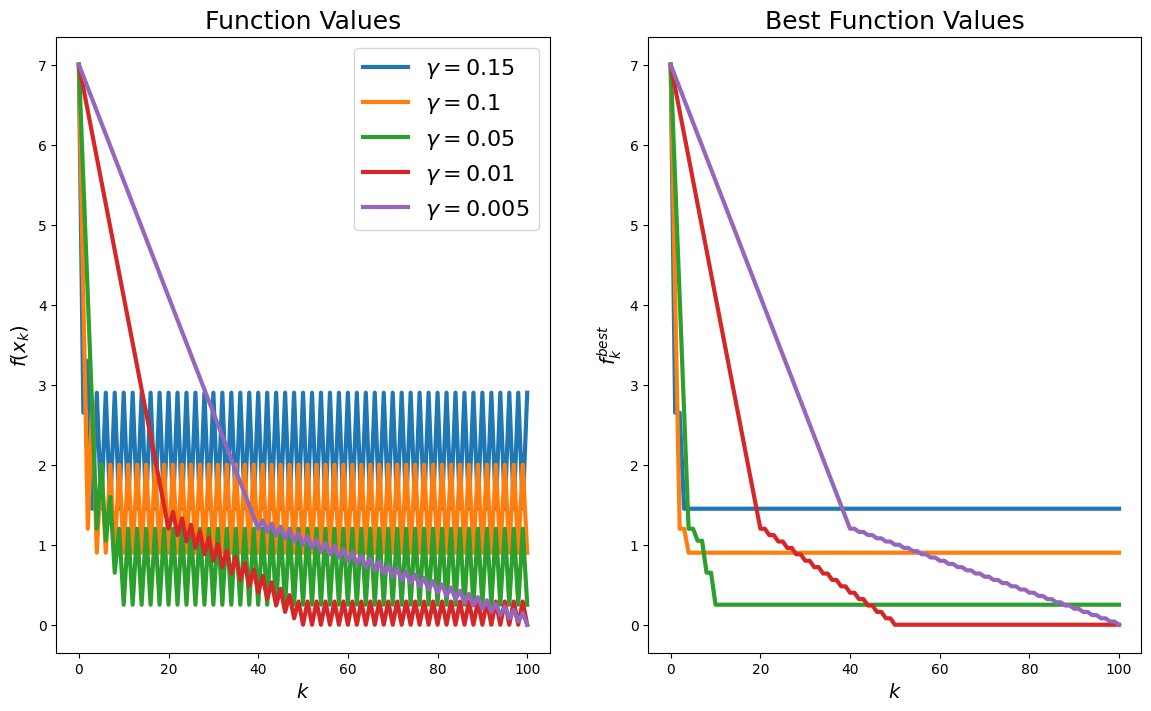

In [90]:
fig, (ax1, ax2)= plt.subplots(1, 2, figsize=(14, 8))
for (i, gamma) in enumerate(gammas):
  ax1.plot(range(function_values[i].shape[0]), function_values[i],'-', lw=3, label="$\gamma = {}$".format(gamma))
  ax2.plot(range(best_function_values[i].shape[0]), best_function_values[i],'-', lw=3, label="$\gamma = {}$".format(gamma))
ax1.legend(fontsize=16)
ax1.set_xlabel("$k$", fontsize=14)
ax1.set_ylabel("$f(x_k)$", fontsize=14)
ax2.set_xlabel("$k$", fontsize=14)
ax2.set_ylabel("$f^{best}_k$", fontsize=14)

ax1.set_title("Function Values", fontsize=18)
ax2.set_title("Best Function Values", fontsize=18)


## Exercise 2: Piece-wise linear minimization
Let us now consider $f: \mathbb{R}^{20} \to \mathbb{R}$
$$
f(x) := \max_{i = 1,\cdots, m} (a_i^\intercal x + b_i)
$$

In [91]:
m = 100
d = 20

A = rnd_state.randn(d, m)
b  = rnd_state.randn(m)

In [92]:
def target(x):
  values = A.T.dot(x) + b
  return np.max(values)

In this case, a subgradient $u$ of $f$ at $x$ is $a_j$ such that
$$
j \in \arg\max\limits_{i = 1, \cdots, m} a_i^\intercal x + b_i
$$
Therefore, to sample a subgradient, we can:
1. compute $a_i^\intercal x + b_i$ for $i = 1, \cdots, m$
2. isolate the $j \in \arg\max\limits_{i = 1, \cdots, m} a_i^\intercal x + b_i$
3. sample one at random from $\{a_j\,|\, j \in \arg\max\limits_{i = 1, \cdots, m} a_i^\intercal x + b_i \}$

Let us implement a function `sample_subgrad(x)` that performs these three operations.

___
Useful functions:
- [np.argwhere](https://numpy.org/doc/stable/reference/generated/numpy.argwhere.html)
- [np.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html)
- [np.ndarray.flatten](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html)

In [93]:
def sample_subgrad(x):
  # TODO: sample a subgradient of f at x
  # same as for target
  values = A.T.dot(x) + b
  max_value = np.max(values)

  # search arg max index
  max_indices = np.argwhere(values == max_value).flatten()
  # choose one index randomly
  chosen_idx = np.random.choice(max_indices)
  # flter A
  return A[:, chosen_idx]

Now we can use the `subgrad_method` function implemented previously to minimize $f$

In [94]:
gamma = 0.01
x0 = np.zeros(d)
max_iter = 500
# TODO: minimize function f using subgradient method with constant stepsize
_, f_vals, _, f_best = subgrad_method(x0, gamma, max_iter, target, sample_subgrad)

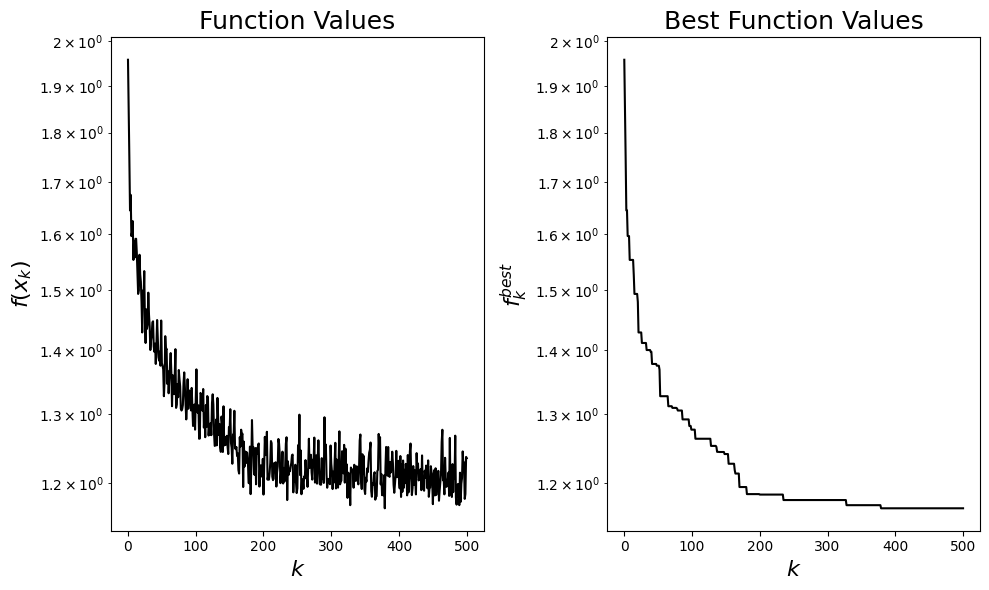

In [95]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.plot(range(f_vals.shape[0]), f_vals, '-', c='black')
ax1.set_yscale('log')
ax1.set_title("Function Values", fontsize=18)
ax2.plot(range(f_best.shape[0]), f_best, '-', c='black')
ax2.set_title("Best Function Values", fontsize=18)
ax2.set_yscale('log')
ax1.set_xlabel("$k$", fontsize=16)
ax2.set_xlabel("$k$", fontsize=16)
ax1.set_ylabel("$f(x_k)$", fontsize=16)
ax2.set_ylabel("$f^{best}_k$", fontsize=16)
fig.tight_layout()

### Step-size:
As we observed, with constant step-size $f^{best}_k - f(x^*)$ does not converge to $0$. As indicated by theory, there are several ways to set the step in subgradient method. In this part we will focus on the following step-sizes:
- Costant $\gamma_k = \gamma$.
$$
f^{best}_k - f(x^*) \leq \frac{\| x_0 - x^* \|_2^2 + L^2 \gamma^2 k}{2 \gamma k}.
$$
- Constant Step-length: $\gamma_k = \gamma / \| u_k \|_2$
$$
f^{best}_k - f(x^*) \leq \frac{\| x_0 - x^* \|_2^2 +  \gamma^2 (k+1)}{2 \gamma (k+1) / L}.
$$
- Monroe: $\gamma_k \not\in \ell^1$ e $\gamma_k^2 \in \ell^1$. With this step size (e.g. $\gamma_k = \gamma k^{- \theta}$ with $1 \geq \theta > 1/2$), $f^{best}_k - f(x^*)$ converges to zero.


### Step-size:
As we observed, with constant step-size $f^{best}_k - f(x^*)$ does not converge to $0$. As indicated by theory, there are several ways to set the step in subgradient method. In this part we will focus on the following step-sizes:
- Costant $\gamma_k = \gamma$.
$$
f^{best}_k - f(x^*) \leq \frac{\| x_0 - x^* \|_2^2}{2 \gamma (k+1)} + \frac{L^2 \gamma}{2}.
$$
- Constant Step-length: $\gamma_k = \gamma / \| u_k \|_2$
$$
f^{best}_k - f(x^*) \leq \frac{L \| x_0 - x^* \|_2^2}{2 \gamma (k+1)} +  \frac{L \gamma}{2}.
$$
- Robbins–Monro 1:
$$
\gamma_k = \gamma (k+1)^{- \theta} \ \text{ with } \ \theta \in [1/2, 1]
$$
With this step-size we have $f^{best}_k - f(x^*)$ converges to zero and, whenever $\theta > 1/2$, $x_k \to x^*$
- Robbins–Monro 2: with the step size
$$
\gamma_k = \frac{\gamma}{\sqrt{(k+1)(1+\log(1+k))^\alpha}} \ \text{ with } \ \alpha \geq 0
$$
With this step-size we have $f^{best}_k - f(x^*)$ converges to zero and, whenever $\alpha > 1/2$, $x_k \to x^*$

In [96]:
def build_stepsize(stepsize_type, gamma):
# k is supposed to range between 0 and max_iter
  def constant_stepsize(u_k, k):
    return gamma

  def constant_step_length(u_k, k):
    # TODO: return constant step length
    L_2 = np.linalg.norm(u_k, ord=2)
    return gamma / L_2

  def monro_1A_stepsize(u_k, k):
    # TODO: return monro 1 with theta=1/2
    theta = 1/2
    return gamma * (k+1)**(-theta)

  def monro_1B_stepsize(u_k, k):
    # TODO: return monro 1 with theta=2/3
    theta = 2/3
    return gamma * (k+1)**(-theta)

  def monro_2_stepsize(u_k, k):
    # TODO: return monro 2 with alpha=1
    alpha = 1
    return gamma / (np.sqrt((k+1) * (1 + np.log(1 + k))**alpha))

  if stepsize_type == 'constant':
    return constant_stepsize
  elif stepsize_type == 'const_steplength':
    return constant_step_length
  elif stepsize_type == 'monro_1A':
    return monro_1A_stepsize
  elif stepsize_type == 'monro_1B':
    return monro_1B_stepsize
  elif stepsize_type == 'monro_2':
    return monro_2_stepsize

Let us now modify the code for subgradient method to support a stepsize function. Specifically, the function `subgrad_method` will have the following definition
```
subgrad_method(x0, stepsize, max_iter, target, sample_subgrad)
```
where `stepsize` is a function that computes the step.

In [97]:
def subgrad_method(x0, stepsize, max_iter, target, sample_subgrad):
  f_vals = np.empty(max_iter + 1)
  f_best = np.empty(max_iter + 1)
  x_obs = np.empty((max_iter + 1, x0.shape[0]))
  x = x0.copy()
  f_min = target(x) # best f(x)
  f_vals[0] = f_min
  f_best[0] = f_min
  x_obs[0] = x.copy()

  for t in range(max_iter):
    u = sample_subgrad(x).flatten()
    # TODO: compute the stepsize
    gamma = stepsize(u, t)
    # TODO: update x by computing the subgradient method iterate
    x = x - gamma * u
    fx = target(x)
    f_vals[t+1] = fx
    x_obs[t+1] = x.copy()
    if f_min > fx:
      f_min = fx
    f_best[t+1] = f_min
  return x, f_vals, x_obs, f_best


Compare the performance of subgradient method using **constant** step considering different values of $\gamma$.

In [98]:
gammas = [0.4, 0.1, 0.05, 0.01]

f_vals = []
f_bests = []

max_iter = 1000
x0 = np.ones(d)

# TODO: run subgrad descent with constant step size and save function values and f_best(x) in the two lists
for gamma in gammas:
  stepsize_fun = build_stepsize("constant", gamma)
  # target and sample_subgrad are fubctions
  _, fv, _, fb = subgrad_method(x0, stepsize_fun, max_iter, target, sample_subgrad)
  f_vals.append(fv)
  f_bests.append(fb)

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2455/2559206727.py:3: SyntaxWarning: invalid escape sequence '\g'
  ax1.plot(range(len(f_vals[i])), f_vals[i], '-', label="$\gamma = {}$".format(gamma))
/tmp/ipykernel_2455/2559206727.py:4: SyntaxWarning: invalid escape sequence '\g'
  ax2.plot(range(len(f_bests[i])), f_bests[i], '-', label="$\gamma = {}$".format(gamma))


Text(0.5, 1.0, 'Best Function Values')

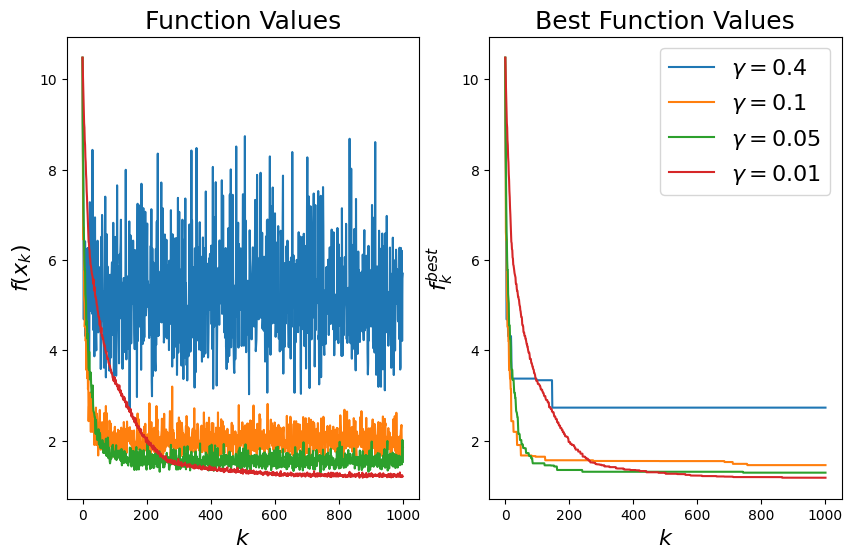

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
for (i, gamma) in enumerate(gammas):
  ax1.plot(range(len(f_vals[i])), f_vals[i], '-', label="$\gamma = {}$".format(gamma))
  ax2.plot(range(len(f_bests[i])), f_bests[i], '-', label="$\gamma = {}$".format(gamma))

ax1.set_xlabel("$k$", fontsize=16)
ax2.set_xlabel("$k$", fontsize=16)
ax1.set_ylabel("$f(x_k)$", fontsize=16)
ax2.set_ylabel("$f^{best}_k$", fontsize=16)
ax2.legend(fontsize=16)
ax1.set_title("Function Values", fontsize=18)
ax2.set_title("Best Function Values", fontsize=18)


Repeat the same procedure using the stepsize $\gamma_k = \gamma / \| u_k \|_2$

In [100]:
gammas = [0.4, 0.1, 0.05, 0.01]

f_vals = []
f_bests = []
x0 = np.zeros(d)
max_iter = 1000

for gamma in gammas:
  stepsize_fun = build_stepsize('const_steplength', gamma)
  _, fv, _, fb = subgrad_method(x0, stepsize_fun, max_iter, target, sample_subgrad)
  f_vals.append(fv)
  f_bests.append(fb)

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2455/2337500208.py:3: SyntaxWarning: invalid escape sequence '\g'
  ax1.plot(range(len(f_vals[i])), f_vals[i], '-', label="$\gamma = {}$".format(gamma))
/tmp/ipykernel_2455/2337500208.py:4: SyntaxWarning: invalid escape sequence '\g'
  ax2.plot(range(len(f_bests[i])), f_bests[i], '-', label="$\gamma = {}$".format(gamma))


Text(0.5, 1.0, 'Best Function Values')

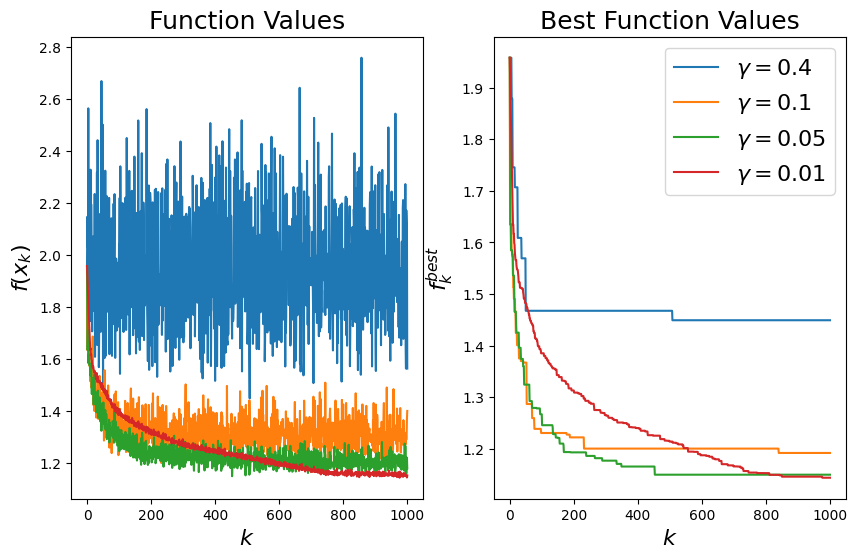

In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
for (i, gamma) in enumerate(gammas):
  ax1.plot(range(len(f_vals[i])), f_vals[i], '-', label="$\gamma = {}$".format(gamma))
  ax2.plot(range(len(f_bests[i])), f_bests[i], '-', label="$\gamma = {}$".format(gamma))

ax1.set_xlabel("$k$", fontsize=16)
ax2.set_xlabel("$k$", fontsize=16)
ax1.set_ylabel("$f(x_k)$", fontsize=16)
ax2.set_ylabel("$f^{best}_k$", fontsize=16)
ax2.legend(fontsize=16)
ax1.set_title("Function Values", fontsize=18)
ax2.set_title("Best Function Values", fontsize=18)

Repeat the same procedure using Robbin-Monro 1A, 1B, 2 stepsize

<>:21: SyntaxWarning: invalid escape sequence '\g'
<>:22: SyntaxWarning: invalid escape sequence '\g'
<>:21: SyntaxWarning: invalid escape sequence '\g'
<>:22: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2455/2708096743.py:21: SyntaxWarning: invalid escape sequence '\g'
  ax1.plot(range(len(f_vals[i])), f_vals[i], '-', label="$\gamma = {}$".format(gamma))
/tmp/ipykernel_2455/2708096743.py:22: SyntaxWarning: invalid escape sequence '\g'
  ax2.plot(range(len(f_bests[i])), f_bests[i], '-', label="$\gamma = {}$".format(gamma))


Performance of sugradient method with 'monro_1A' stepsize:
Performance of sugradient method with 'monro_1B' stepsize:
Performance of sugradient method with 'monro_2' stepsize:


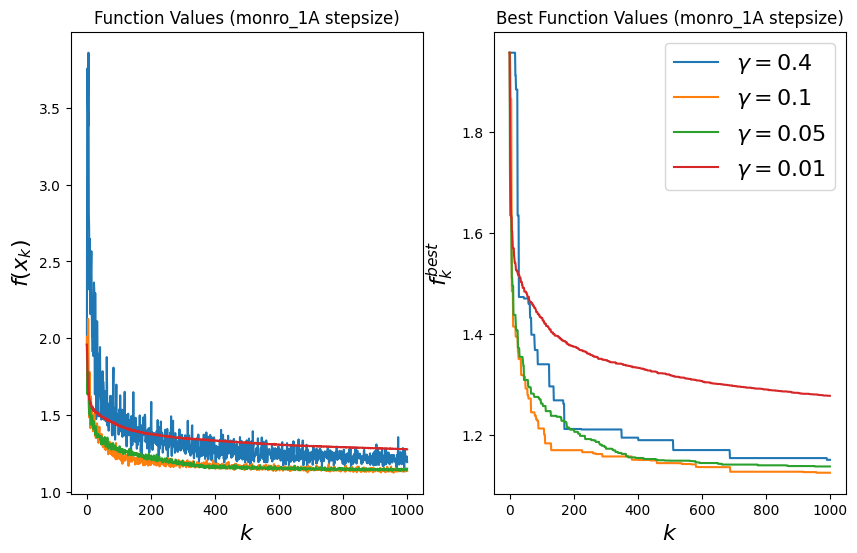

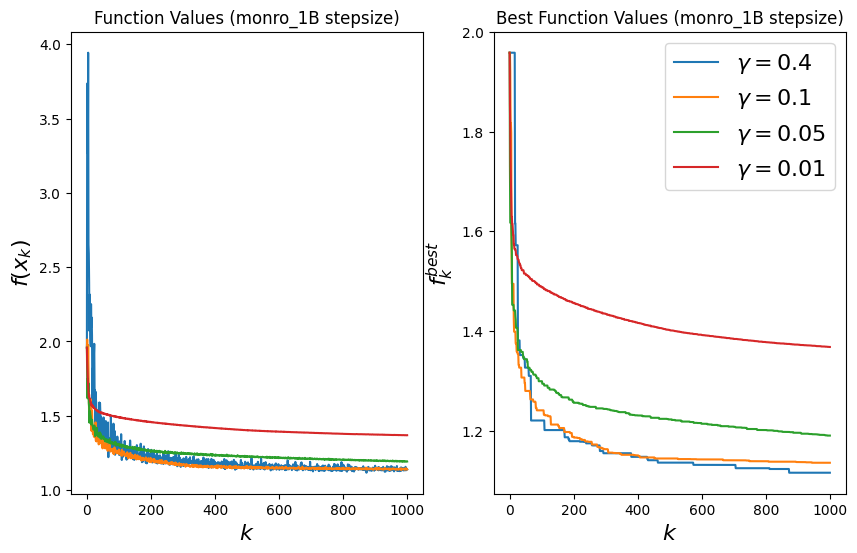

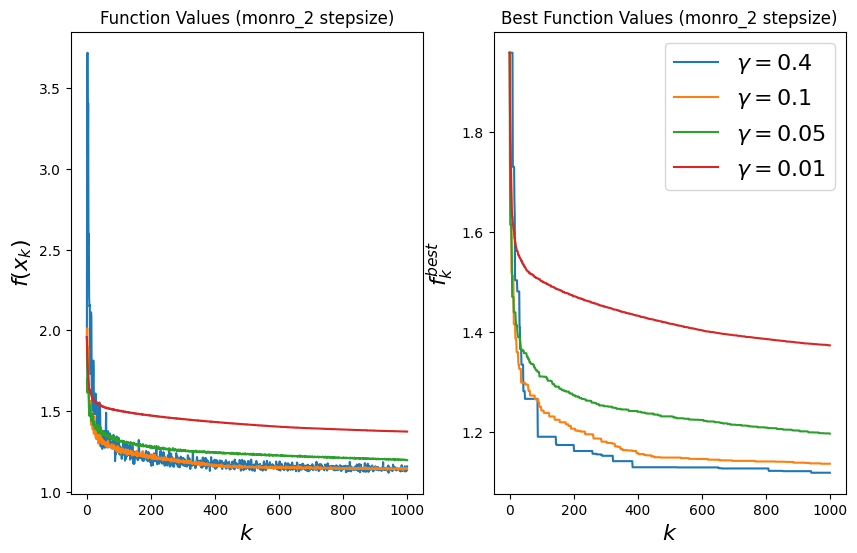

In [102]:
# TODO: Insert your code here
gammas = [0.4, 0.1, 0.05, 0.01]

def plot_performance_of_subgradient_method(stepsize_type, gammas):
  # init values for subgradient method
  f_vals = []
  f_bests = []
  x0 = np.zeros(d)
  max_iter = 1000

  # find f values and best
  for gamma in gammas:
    stepsize_fun = build_stepsize(stepsize_type, gamma)
    _, fv, _, fb = subgrad_method(x0, stepsize_fun, max_iter, target, sample_subgrad)
    f_vals.append(fv)
    f_bests.append(fb)

  # plot
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
  for (i, gamma) in enumerate(gammas):
    ax1.plot(range(len(f_vals[i])), f_vals[i], '-', label="$\gamma = {}$".format(gamma))
    ax2.plot(range(len(f_bests[i])), f_bests[i], '-', label="$\gamma = {}$".format(gamma))

  ax1.set_xlabel("$k$", fontsize=16)
  ax2.set_xlabel("$k$", fontsize=16)
  ax1.set_ylabel("$f(x_k)$", fontsize=16)
  ax2.set_ylabel("$f^{best}_k$", fontsize=16)
  ax2.legend(fontsize=16)
  ax1.set_title(f"Function Values ({stepsize_type} stepsize)", fontsize=12)
  ax2.set_title(f"Best Function Values ({stepsize_type} stepsize)", fontsize=12)


# run for Robbin-Monro 1A, 1B, 2
stepsize_types = ['monro_1A', 'monro_1B', 'monro_2']
for stepsize_type in stepsize_types:
  print(f"Performance of sugradient method with '{stepsize_type}' stepsize:")
  plot_performance_of_subgradient_method(stepsize_type, gammas)

Now fix a constant $\gamma > 0$ and compare the different stepsizes

In [103]:
gamma = 0.2

f_vals = []
f_bests = []
x0 = np.zeros(d)
max_iter = 10000

for stype in ['constant', 'const_steplength', 'monro_1A', 'monro_1B', 'monro_2']:
  # TODO: use build_stepsize
  print(stype)
  stepsize_fun = build_stepsize(stype, gamma)
  # TODO: run subgrad descent
  _, fv, _, fb = subgrad_method(x0, stepsize_fun, max_iter, target, sample_subgrad)
  f_vals.append(fv)
  f_bests.append(fb)

constant
const_steplength
monro_1A
monro_1B
monro_2


Text(0.5, 1.0, 'Best Function Values')

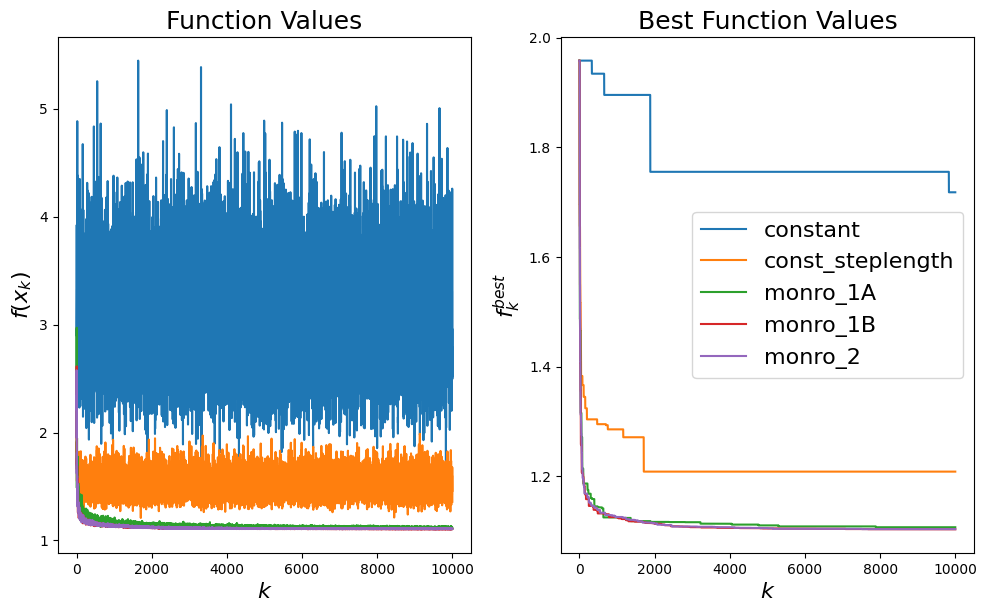

In [104]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
for (i, gamma) in enumerate(['constant', 'const_steplength', 'monro_1A', 'monro_1B', 'monro_2']):
  ax1.plot(range(len(f_vals[i])),   f_vals[i], '-', label="{}".format(gamma))
  ax2.plot(range(len(f_bests[i])), f_bests[i], '-', label="{}".format(gamma))

ax1.set_xlabel("$k$", fontsize=16)
ax2.set_xlabel("$k$", fontsize=16)
ax1.set_ylabel("$f(x_k)$", fontsize=16)
ax2.set_ylabel("$f^{best}_k$", fontsize=16)
fig.tight_layout()
ax2.legend(fontsize=16)
ax1.set_title("Function Values", fontsize=18)
ax2.set_title("Best Function Values", fontsize=18)

## Polyak Stepsize
In some problems, in addition to the gradient, we have access to the global minimum information (i.e. $\min f$ is known and we want to find $x \in \arg\min f$).

In this setting, we can exploit this information for the step-size selection.

**Polyak stepsize**: sia $f_{min} := \min\limits_{x \in \mathbb{R}^d} f(x)$, we define
$$
\gamma_k = \frac{f(x_k) - f_{min}}{\| u_k \|_2^2}
$$

However, if we consider the previous minimization problem, we do not have the minimum information. In this case, we can approximate the Polyak stepsize as follows

$$
\gamma_k = \frac{f(x_k) - f^{best}_k + \alpha_k}{\| u_k \|_2^2}
$$

with $\alpha_k \in \ell^1$.

Note that we need to (again) extend the code of `subgrad_method`. Specifically, the stepsize function will also need to take as parameter the current iterate $x_k$.

Therefore, the function will be defined as `subgrad_method(x0, stepsize, max_iter, target, sample_subgrad)` where `stepsize` will in turn be a function defined as follows
```
stepsize(fx, fx_best, u, k)
```
where
- `fx` is $f(x_k)$
- `fx_best` is $f^{best}_k$
- `u` is the sampled subgradient
- `k` is the current iteration


In [112]:
def subgrad_method(x0, stepsize, max_iter, target, sample_subgrad):
  f_vals = np.empty(max_iter + 1)
  f_best = np.empty(max_iter + 1)
  x_obs = np.empty((max_iter + 1, x0.shape[0]))
  x = x0.copy()
  f_min = target(x) # best f(x)
  f_vals[0] = f_min
  f_best[0] = f_min
  x_obs[0] = x.copy()

  for t in range(max_iter):
    u = sample_subgrad(x).flatten()
    # TODO: compute the stepsize
    gamma = stepsize(f_vals[t], f_best[t], u, t)
    # TODO: update x by computing the subgradient method iterate
    x = x - gamma * u
    fx = target(x)
    f_vals[t + 1] = fx
    x_obs[t + 1] = x.copy()
    if f_min > fx:
      f_min = fx
    f_best[t + 1] = f_min
  return x, f_vals, x_obs, f_best


Implement the Polyak stepsize and compare it with other step-sizes

In [111]:
def polyak_stepsize(fx, f_best, u, k):
  alpha_k = 20 / (10 + k)
  # TODO: return polyak stepsize (remember that f_min = 0)
  L_2_squared = np.linalg.norm(u, ord=2)**2
  return (fx - f_best + alpha_k) / L_2_squared

def monro_1A_stepsize(fx, f_best, u, k):
  gamma = 0.1
  theta = 1/2
  return gamma * (k+1)**(-theta)

def constant_stepsize(fx, f_best, u, k):
  return 0.01

In [113]:
max_iter = 1000

f_values = []
f_bsts = []
x0 = np.zeros(d)

for step_f in [constant_stepsize, monro_1A_stepsize, polyak_stepsize]:
  # TODO: run subgradient method
  x, f_vals, x_obs, f_best = subgrad_method(x0, step_f, max_iter, target, sample_subgrad)
  f_values.append(f_vals)
  f_bsts.append(f_best)

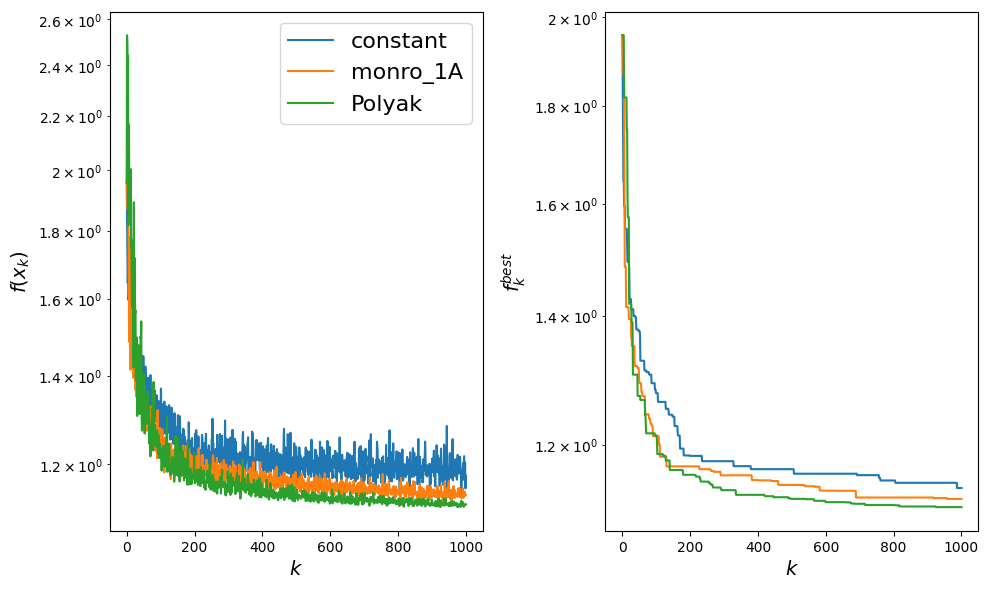

In [115]:
labels = ['constant', 'monro_1A', 'Polyak']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
for i in range(len([constant_stepsize, monro_1A_stepsize, polyak_stepsize])):
  ax1.plot(range(f_values[i].shape[0]), f_values[i], '-', label=labels[i])
  ax2.plot(range(f_bsts[i].shape[0]), f_bsts[i], '-', label=labels[i])
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.set_ylabel("$f(x_k)$", fontsize=14)
ax2.set_ylabel("$f^{best}_k$", fontsize=14)
ax1.set_xlabel("$k$", fontsize=14)
ax2.set_xlabel("$k$", fontsize=14)
fig.tight_layout()
ax1.legend(fontsize=16)